In [6]:
#redoing the replication code bc it needs to be productive assets to be Balboni style
# QSS 20 Final Project
# Cooper Hindshaw

# 04_replication_analysis_v2.ipynb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


df = pd.read_stata("../dataverse_files/UCT_FINAL_CLEAN.dta")

df = df.drop_duplicates(subset="surveyid").copy()


# Keep observations with both baseline and follow-up assets
rep = df[
    ["surveyid",
     "treat",
     "asset_total_ppp0",
     "asset_total_ppp1"]
    ].dropna().copy()

# Renaming var to make easier to read
rep = rep.rename(
    columns={"asset_total_ppp0": "assets_baseline",
             "asset_total_ppp1": "assets_followup"})

for var in [
    "asset_livestock_ppp0",
    "asset_durable_ppp0",
    "asset_ag_ppp0",
    "asset_trans_ppp0",
    "durable_investment0"]:
    print(var)

reader = pd.io.stata.StataReader(
    "../dataverse_files/UCT_FINAL_CLEAN.dta")

labels = reader.variable_labels()

for var in [
    "asset_livestock_ppp0",
    "asset_durable_ppp0",
    "asset_ag_ppp0",
    "asset_trans_ppp0",
    "durable_investment0"]:
    print(var, ":", labels[var])
    

asset_livestock_ppp0
asset_durable_ppp0
asset_ag_ppp0
asset_trans_ppp0
durable_investment0
asset_livestock_ppp0 : Value of livestock (USD)
asset_durable_ppp0 : Value of durable goods (USD)
asset_ag_ppp0 : \hspace{0.2cm}Value of agricultural tools (USD)
asset_trans_ppp0 : \hspace{0.2cm}Value of bike/motorbike (USD)
durable_investment0 : Durable Investments


In [7]:
reader = pd.io.stata.StataReader(
    "../dataverse_files/UCT_FINAL_CLEAN.dta")

labels = reader.variable_labels()

for var in df.columns:
    if any(word in var.lower() for word in
           ["large", "small", "amount", "transfer", "lump", "monthly", "size", "asset", "land"]):
        print(var, ":", labels.get(var))

df[["treat", "treatXlarge", "treatXsmall"]].value_counts()

rep["treatment_group"] = np.select(
    [(df["treat"] == 0),(df["treatXsmall"] == 1),(df["treatXlarge"] == 1)],
    ["Control","Small Transfer","Large Transfer"],default="Other")

rep["treatment_group"].value_counts()

treatXlump : Treatment x Lump sum transfer
treatXmonthly : Treatment x Monthly transfer
treatXlarge : Treatment x Large transfer
treatXsmall : Treatment x Small transfer
treatXmalerecXlump : Treatment x Male recipient x Lump sum transfer
treatXmalerecXsmall : Treatment x Male recipient x Small transfer
treatXlumpXsmall : Treatment x Lump sum transfer x Small transfer
treatXmalerecXlumpXsmall : Treatment x Male recipient x Lump sum transfer x Small transfer
treatXmalerecXlarge : Treatment x Male recipient x Large transfer
treatXlumpXlarge : Treatment x Lump sum transfer x Large transfer
treatXmalerecXlumpXlarge : Treatment x Male recipient x Lump sum transfer x Large transfer
treatXmalerecXmonthly : Treatment x Male recipient x Monthly transfer
treatXmonthlyXsmall : Treatment x Monthly transfer x Small transfer
treatXmalerecXmonthlyXsmall : Treatment x Male recipient x Monthly transfer x Small transfer
treatXmonthlyXlarge : Treatment x Monthly transfer x Large transfer
treatXmalerecXmon

treatment_group
Control           937
Small Transfer    366
Large Transfer    137
Name: count, dtype: int64

In [8]:
# Keep observations with both baseline and follow-up assets

rep["productive_assets_baseline"] = (
    df["asset_livestock_ppp0"]
    + df["asset_ag_ppp0"]
    + df["asset_trans_ppp0"])

rep["productive_assets_followup"] = (
    df["asset_livestock_ppp1"]
    + df["asset_ag_ppp1"]
    + df["asset_trans_ppp1"])

rep["productive_assets_change"]= (rep["productive_assets_followup"] - rep["productive_assets_baseline"])
rep.head()
rep["productive_assets_change"].describe()

# Balboni uses log assets.
# log1p allows households with zero assets to remain in the sample.
rep["log_passets_baseline"] = np.log1p(rep["productive_assets_baseline"])
rep["log_passets_followup"] = np.log1p(rep["productive_assets_followup"])

rep["log_passets_change"]= (rep["log_passets_followup"] - rep["log_passets_baseline"])




In [9]:
print(rep.groupby("treatment_group")["productive_assets_baseline"].describe())


                 count        mean         std  min        25%        50%  \
treatment_group                                                             
Control          937.0  108.405800  239.135834  0.0   0.000000   5.605380   
Large Transfer   137.0  199.820969  310.754456  0.0  30.260796  93.905396   
Small Transfer   366.0  195.334290  282.984711  0.0  26.224223  78.578613   

                        75%          max  
treatment_group                           
Control          101.436440  2839.413086  
Large Transfer   220.687454  2254.915771  
Small Transfer   230.873413  2034.891357  


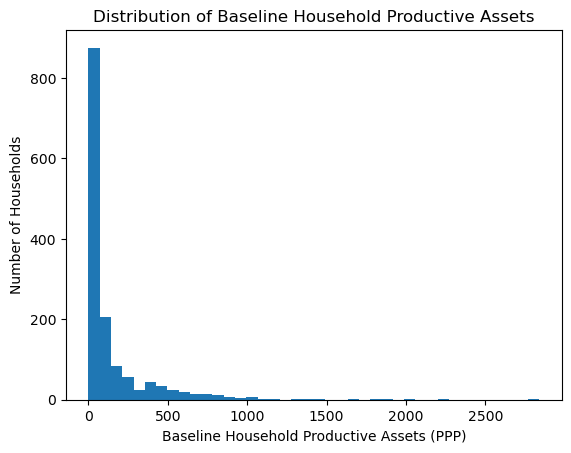

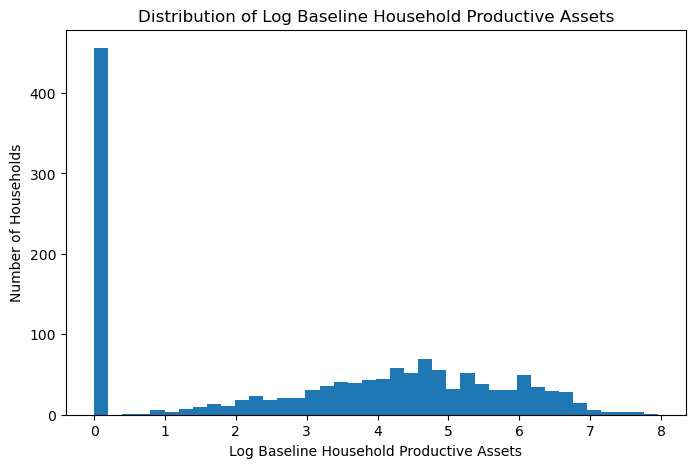

In [10]:
# Baseline Distribution
# Balboni style exploratory analysis

plt.hist(
    rep["productive_assets_baseline"],
    bins=40)

plt.xlabel("Baseline Household Productive Assets (PPP)")
plt.ylabel("Number of Households")
plt.title("Distribution of Baseline Household Productive Assets")


plt.savefig(
    "../output/replication_baseline_passet_distribution.png",
    bbox_inches="tight")
plt.show()


# 4. LOG BASELINE ASSET DISTRIBUTION
# Makes the distribution easier to examine because
# asset holdings are highly skewed

plt.figure(figsize=(8, 5))

plt.hist(
    rep["log_passets_baseline"],
    bins=40)

plt.xlabel("Log Baseline Household Productive Assets")
plt.ylabel("Number of Households")
plt.title("Distribution of Log Baseline Household Productive Assets")


plt.savefig(
    "../output/replication_log_passet_distribution.png",
    bbox_inches="tight")

plt.show()






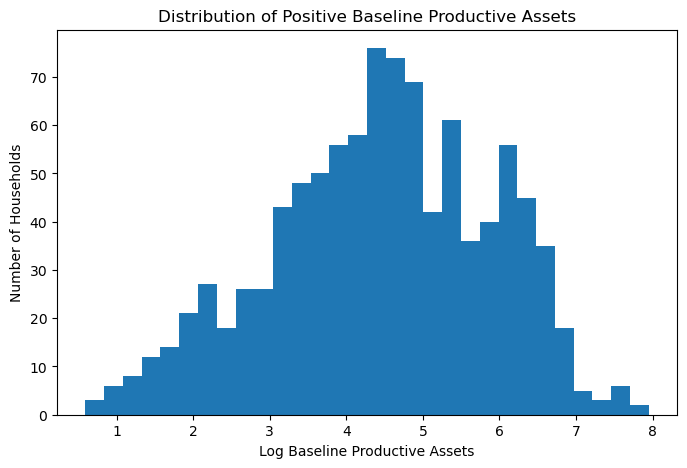

In [11]:
#exploring w/o the zero category just to see dist, but keeping the 0 in bc its is possible to have 0 productive assets

positive_assets = rep.loc[
    rep["productive_assets_baseline"] > 0,
    "log_passets_baseline"]

plt.figure(figsize=(8, 5))

plt.hist(
    positive_assets,
    bins=30)

plt.xlabel("Log Baseline Productive Assets")
plt.ylabel("Number of Households")
plt.title("Distribution of Positive Baseline Productive Assets")

plt.show()

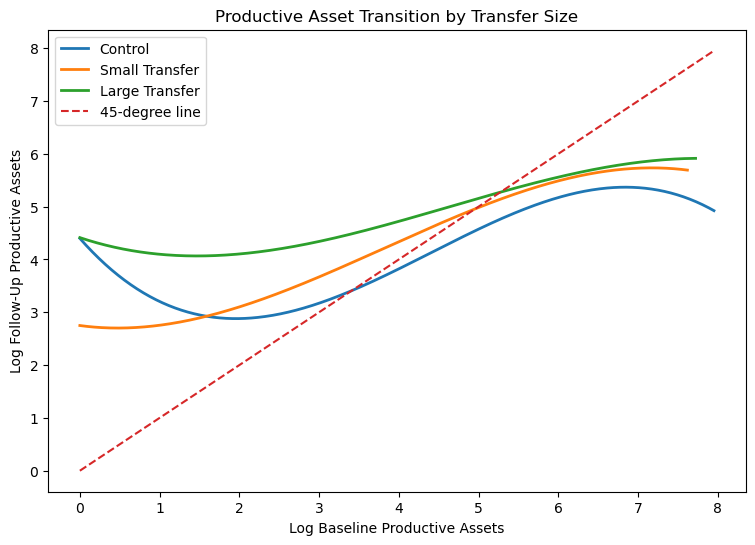

In [18]:
# 2. Productive-asset transition curves by treatment group

plt.figure(figsize=(9, 6))

for group_name in [
    "Control",
    "Small Transfer",
    "Large Transfer"]:

    group = rep[
        rep["treatment_group"] == group_name].dropna(
        subset=["log_passets_baseline","log_passets_followup"])

    x = group["log_passets_baseline"].values
    y = group["log_passets_followup"].values

    model = np.polyfit(x, y, 3)
    function = np.poly1d(model)

    x_smooth = np.linspace(x.min(), x.max(), 500)

    plt.plot(
        x_smooth,
        function(x_smooth),
        linewidth=2,
        label=group_name)

# 45-degree line
minimum = rep["log_passets_baseline"].min()
maximum = rep["log_passets_baseline"].max()

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--",
    label="45-degree line"
)

plt.xlabel("Log Baseline Productive Assets")
plt.ylabel("Log Follow-Up Productive Assets")
plt.title("Productive Asset Transition by Transfer Size")

plt.legend()

plt.savefig(
    "../output/cubic_transition.png",
    bbox_inches="tight"
)

plt.show()

In [13]:
# 3. Candidate thresholds and slopes by treatment group

for group_name in [
    "Control",
    "Small Transfer",
    "Large Transfer"]:

    group = rep[
        rep["treatment_group"] == group_name].dropna(
        subset=[
            "log_passets_baseline",
            "log_passets_followup"])

    x = group["log_passets_baseline"].values
    y = group["log_passets_followup"].values

    model = np.polyfit(x, y, 3)
    function = np.poly1d(model)

    # Find where fitted curve crosses 45-degree line
    difference = function - np.poly1d([1, 0])

    roots = np.roots(difference)

    real_roots = [
        root.real
        for root in roots
        if np.isreal(root)
        and x.min() <= root.real <= x.max()]

    derivative = np.polyder(function)

    print("\n" + group_name)

    if len(real_roots) == 0:
        print("No candidate threshold found")

    for threshold in real_roots:

        asset_threshold = np.expm1(threshold)
        slope = derivative(threshold)

        print(
            "Log threshold:",
            round(threshold, 3),
            "| PPP assets:",
            round(asset_threshold, 2),
            "| slope:",
            round(slope, 3))


Control
Log threshold: 3.408 | PPP assets: 29.21 | slope: 0.638

Small Transfer
Log threshold: 4.959 | PPP assets: 141.43 | slope: 0.601

Large Transfer
Log threshold: 5.274 | PPP assets: 194.21 | slope: 0.421


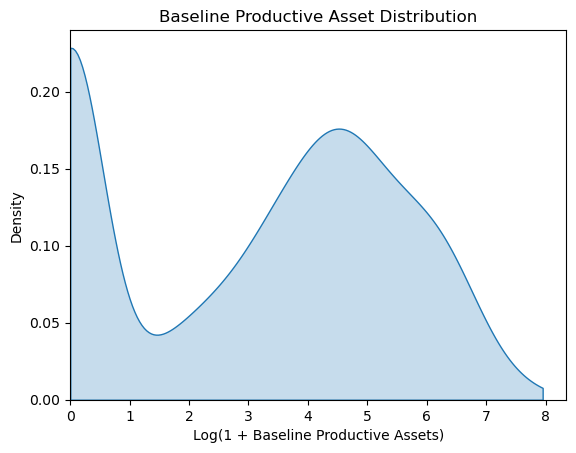

In [16]:
import seaborn as sns


sns.kdeplot(
    data=rep,
    x="log_passets_baseline",
    fill=True,
    cut=0,
    clip=(0, None)
)

plt.xlim(left=0)
plt.xlabel("Log(1 + Baseline Productive Assets)")
plt.ylabel("Density")
plt.title("Baseline Productive Asset Distribution")

plt.savefig(
    "../output/baseline_KDE.png",
    bbox_inches="tight"
)

plt.show()

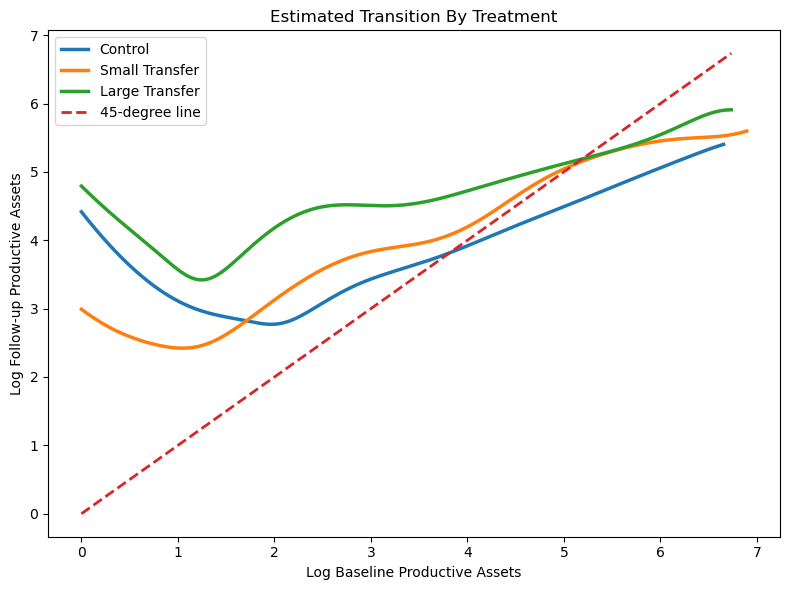

In [17]:
from statsmodels.nonparametric.kernel_regression import KernelReg


plt.figure(figsize=(8, 6))


for group_name in ["Control", "Small Transfer", "Large Transfer"]:

    group = rep.loc[
        rep["treatment_group"] == group_name,
        ["log_passets_baseline", "log_passets_followup"]
    ].dropna()

    X = group["log_passets_baseline"].to_numpy()
    Y = group["log_passets_followup"].to_numpy()

    # Kernel-weighted local linear regression
    # Manually set bandwidth because automatic bandwidth
    # performs poorly with repeated asset values / mass at zero
    kr = KernelReg(
        endog=Y,
        exog=X,
        var_type="c",
        reg_type="ll",
        bw=[0.6]
    )

    # Avoid very sparse extreme upper tail
    upper = np.percentile(X, 97.5)

    X_plot = np.linspace(
        X.min(),
        upper,
        300
    )

    Y_pred, _ = kr.fit(X_plot)


    # Transition function
    plt.plot(
        X_plot,
        Y_pred,
        linewidth=2.5,
        label=group_name
    )

    # 45-degree line
plt.plot(
        X_plot,
        X_plot,
        linestyle="--",
        linewidth=2,
        label="45-degree line"
    )

plt.xlabel("Log Baseline Productive Assets")
plt.ylabel("Log Follow-up Productive Assets")
plt.title("Estimated Transition By Treatment")

plt.legend()
plt.tight_layout()
plt.savefig(
    "../output/kernel_transition.png",
    bbox_inches="tight"
)

plt.show()

SyntaxError: unterminated string literal (detected at line 1) (3488842185.py, line 1)

In [14]:


groups = ["Control", "Small Transfer", "Large Transfer"]

for group_name in groups:

    group = rep.loc[
        rep["treatment_group"] == group_name,
        ["log_passets_baseline", "log_passets_followup"]].dropna()

    X = group["log_passets_baseline"].to_numpy()
    Y = group["log_passets_followup"].to_numpy()

    kr = KernelReg(
        endog=Y,
        exog=X,
        var_type="c",
        reg_type="ll",
        bw=[0.6])

    X_plot = np.linspace(
        np.percentile(X, 2.5),
        np.percentile(X, 97.5),
        1000)

    Y_pred, marginal_effects = kr.fit(X_plot)

    slopes = marginal_effects[:, 0]
    difference = Y_pred - X_plot

    crossing_idx = np.where(
        np.sign(difference[:-1]) != np.sign(difference[1:]))[0]

    print("\n" + group_name)
    print("Number of crossings:", len(crossing_idx))

    for idx in crossing_idx:

        crossing_log = X_plot[idx]
        crossing_ppp = np.expm1(crossing_log)

        print("Crossing log:",
              round(crossing_log, 3),
              "| Crossing PPP:",
              round(crossing_ppp, 2),
              "| Local slope:",
              round(slopes[idx], 3))


Control
Number of crossings: 1
Crossing log: 3.811 | Crossing PPP: 44.21 | Local slope: 0.56

Small Transfer
Number of crossings: 1
Crossing log: 5.107 | Crossing PPP: 164.12 | Local slope: 0.631

Large Transfer
Number of crossings: 1
Crossing log: 5.189 | Crossing PPP: 178.28 | Local slope: 0.367
